In [4]:
import pandas as pd
import numpy as np

In [5]:
treatments_df = pd.read_csv('treatments.csv')
treatments_cut_df = pd.read_csv('treatments_cut.csv')
patients_df = pd.read_csv('patients.csv')
adverse_reactions_df = pd.read_csv('adverse_reactions.csv')

In [6]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


# Summary of the Data
This dataset contains information about approximately 500 patients, out of which 350 participated in a clinical trial. None of these patients were using Novodra (a popular injectable insulin) or Auralin (an oral insulin under research) as their primary insulin source before the trial. All patients had elevated HbA1c levels.

To establish a baseline HbA1c level and insulin dosage, all 350 patients were initially treated with Novodra. After 4 weeks—an interval not sufficient to capture the full HbA1c changes—patients were split into two groups for the next 24 weeks:
- 175 patients switched to Auralin
-  175 patients continued using Novodra

The dataset also includes information about patients who experienced adverse effects during the trial.

## patients_df
### Issues with the Data -->
### Dirty data:
- missing values of columns are address city, state, zip_code, country, contact, phone, email id. 
- 5 repeatedly entries of a person(john Doe). 
- Cities are written with their state abbreviation, such as San Diego, CA; New York, NY; Chicago, IL; and Sacramento, CA. 
- phone number is repeated. 
- repeatedly given_name and surname with misleading words.
- sometimes zip code has 4 digits only.
- misspelled of name and surname.
- someone has weight 48.8 pounds(lb) and 63 inches height and BMI is 19.1
- repeatating email id.
- person name with David has misplelled as the name Dsvid .
- Name and surname somwhere is in small letter of the starting letter of name,surname.
### Messy data:
- contact column included both mobile number and Email Id.

In [7]:
missing_p = patients_df.isnull().sum()
missing_p

patient_id       0
assigned_sex     0
given_name       0
surname          0
address         12
city            12
state           12
zip_code        12
country         12
contact         12
birthdate        0
weight           0
height           0
bmi              0
dtype: int64

In [8]:
missing_p[missing_p !=0]

address     12
city        12
state       12
zip_code    12
country     12
contact     12
dtype: int64

In [9]:
patients_df[['given_name' , 'surname']].duplicated().sum()

np.int64(5)

In [10]:
patients_df[patients_df[['given_name' , 'surname']].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [11]:
patients_df['zip_code']

0      92390.0
1      61812.0
2      68467.0
3       7095.0
4      36303.0
        ...   
498     3852.0
499    86341.0
500    64110.0
501    98109.0
502    68324.0
Name: zip_code, Length: 503, dtype: float64

In [12]:
patients_df['zip_code'].describe()

count      491.000000
mean     49084.118126
std      30265.807442
min       1002.000000
25%      21920.500000
50%      48057.000000
75%      75679.000000
max      99701.000000
Name: zip_code, dtype: float64

In [13]:
patients_df['zip_code'].astype(str).str.len().sort_values(ascending = True).head(18)

269    3
219    3
230    3
234    3
296    3
242    3
286    3
249    3
257    3
278    3
209    3
264    3
78     6
44     6
124    6
167    6
92     6
53     6
Name: zip_code, dtype: int64

In [14]:
patients_df['city'].value_counts(ascending = False).head(28)

city
New York         18
San Diego         8
Tulsa             7
Atlanta           6
Houston           6
Chicago           6
Los Angeles       5
Pittsburgh        5
Philadelphia      5
Sacramento        4
New Orleans       4
San Antonio       4
Portland          4
Providence        4
Westbury          3
San Jose          3
Lombard           3
Oklahoma City     3
Hartford          3
Seattle           3
Bedford           3
Garden City       3
Manhattan         3
Tampa             3
Boston            3
Washington        3
Albany            3
Newport News      3
Name: count, dtype: int64

In [15]:
patients_df[patients_df['city'] == 'New York']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
9,10,female,Sophie,Cabrera,3303 Anmoore Road,New York,New York,10011.0,United States,SophieCabreraIbarra@teleworm.us1 718 795 9124,12/3/1930,194.7,64,33.4
35,36,female,Kamila,Pecinová,3558 Longview Avenue,New York,New York,10004.0,United States,718-501-0503KamilaPecinova@dayrep.com,12/23/1985,198.9,62,36.4
84,85,female,Nương,Vũ,465 Southern Street,New York,NY,10001.0,United States,VuCamNuong@fleckens.hu516-720-5094,2/1/1981,138.2,63,24.5
129,130,female,Rebecca,Jephcott,989 Wayback Lane,New York,NY,10004.0,United States,631-370-7406RebeccaJephcott@armyspy.com,8/1/1966,203.3,65,33.8
142,143,male,Finley,Chandler,2754 Westwood Avenue,New York,New York,10001.0,United States,516-740-5280FinleyChandler@dayrep.com,10/25/1936,150.9,70,21.6
152,153,male,Christopher,Woodward,3450 Southern Street,New York,NY,10004.0,United States,ChristopherWoodward@jourrapide.com+1 (516) 630...,9/4/1984,212.2,66,34.2
188,189,male,Søren,Sørensen,2397 Bell Street,New York,NY,10011.0,United States,SrenSrensen@superrito.com1 212 201 3108,12/31/1942,157.1,67,24.6
213,214,female,Onyemaechi,Onwughara,685 Duncan Avenue,New York,NY,10013.0,United States,917-622-9142OnyemaechiOnwughara@einrot.com,3/8/1989,131.1,69,19.4
215,216,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [16]:
patients_df[patients_df['city'] == 'Chicago']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
178,179,female,Else,Andersen,1386 Farland Street,Chicago,Illinois,60631.0,United States,773-934-7423ElseAndersen@rhyta.com,6/16/1975,197.1,65,32.8
187,188,male,Władysław,Wieczorek,2338 Virginia Street,Chicago,IL,60605.0,United States,773-607-2647WladyslawWieczorek@teleworm.us,1/15/1994,133.1,67,20.8
191,192,female,Fanette,Fournier,602 Tator Patch Road,Chicago,Illinois,60607.0,United States,FanetteFournier@einrot.com+1 (312) 864-5737,10/24/1938,112.6,60,22.0
283,284,male,Nwachukwu,Nebeolisa,2873 John Calvin Drive,Chicago,IL,60605.0,United States,NwachukwuNebeolisa@cuvox.de+1 (708) 845-2053,3/10/1986,245.5,68,37.3
325,326,female,Sara,Karjalainen,720 Tator Patch Road,Chicago,Illinois,60601.0,United States,SaraKarjalainen@armyspy.com1 312 856 6826,8/20/1946,172.5,63,30.6
447,448,male,Luiz,Gomes,1812 Poplar Street,Chicago,IL,60631.0,United States,708-691-2195LuizCavalcantiGomes@rhyta.com,4/23/1978,160.4,70,23.0


In [17]:
patients_df[patients_df['city'] == 'Sacramento']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
162,163,female,Sarina,Tabata,4646 Highland View Drive,Sacramento,CA,95814.0,United States,SarinaTabata@teleworm.us916-555-7247,4/21/1967,201.7,63,35.7
189,190,female,Kisanet,Selassie,3227 Park Avenue,Sacramento,California,95817.0,United States,KisanetSelassie@gustr.com+1 (916) 453-3601,4/26/1956,177.1,62,32.4
228,229,female,Cintia,Csorba,2126 Pearl Street,Sacramento,California,95826.0,United States,CsorbaCintia@fleckens.hu916-379-7480,7/20/1991,186.6,62,34.1
295,296,male,Albino,Schiavone,3113 Timber Ridge Road,Sacramento,California,95814.0,United States,AlbinoSchiavone@fleckens.hu1 916 817 9960,6/30/1928,180.0,67,28.2


In [18]:
patients_df[patients_df['city'] == 'San Diego']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
60,61,female,Barbora,Vesecká,4018 Poplar Avenue,San Diego,CA,92101.0,United States,619-570-3898BarboraVesecka@gustr.com,2/19/1939,159.1,67,24.9
63,64,male,Yukitaka,Takenaka,1975 Holden Street,San Diego,California,92103.0,United States,619-299-1495YukitakaTakenaka@einrot.com,11/24/1944,193.2,72,26.2
66,67,male,Konstantyn,Kowalczyk,4707 Parkway Street,San Diego,California,92103.0,United States,760-287-8295KonstantynKowalczyk@armyspy.com,3/2/1938,194.3,67,30.4
232,233,female,Kyouko,Ono,435 Pike Street,San Diego,CA,92123.0,United States,KyoukoOno@superrito.com1 858 587 9945,11/19/1940,126.9,59,25.6
287,288,male,Kari,Laatikainen,1231 Grim Avenue,San Diego,CA,92111.0,United States,KariLaatikainen@fleckens.hu1 619 818 3436,3/21/1976,149.6,72,20.3
347,348,female,Urška,Aličajić,3781 Hamill Avenue,San Diego,CA,92109.0,United States,858-273-2043UrskaAlicajic@rhyta.com,6/27/1952,183.3,63,32.5
369,370,female,Farizah,Sleiman,2322 Grim Avenue,San Diego,CA,92101.0,United States,619-652-0285FarizahAminehSleiman@teleworm.us,8/19/1943,190.5,62,34.8
459,460,female,Idalia,Moore,4380 Grim Avenue,San Diego,California,92073.0,United States,619-710-6286IdaliaEMoore@cuvox.de,10/26/1993,102.1,61,19.3


In [19]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [20]:
patients_df['contact'] = patients_df['contact'].replace({'-':'', r'\(':'',r'\)':''}, regex=True)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 217 5693204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 732 6368246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [21]:
patients_df['contact'] = patients_df['contact'].str.replace(' ', '', regex=False)
patients_df['contact'] = patients_df['contact'].str.replace(r'\+1', '', regex=True)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7


In [22]:
patients_df['email'] = patients_df['contact'].str.extract(r'([A-Za-z][A-Za-z0-9._%+-]*@[A-Za-z0-9.-]+\.[A-Za-z]{2,})')
patients_df['phone'] = patients_df['contact'].str.extract(r'(\d{10})')
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


In [23]:
patients_df['phone'].value_counts().sort_values(ascending = False).head(10)

phone
1234567890    6
3044382648    2
8458587707    2
4028484923    2
8162659578    1
2054178095    1
4345092614    1
1931207083    1
9064788949    1
1718795912    1
Name: count, dtype: int64

In [24]:
(patients_df['phone'] == '1234567890').value_counts()

phone
False    497
True       6
Name: count, dtype: int64

In [25]:
patients_df[patients_df['phone'] == '1234567890']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
215,216,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890


In [26]:
patients_df[patients_df['phone'] == '3044382648']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
131,132,female,Sandra,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,3044382648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4,SandraCTaylor@dayrep.com,3044382648
282,283,female,Sandy,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,3044382648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4,SandraCTaylor@dayrep.com,3044382648


In [27]:
patients_df[patients_df['phone'] == '845858770']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone


In [28]:
patients_df[patients_df['phone'] == '4028484923']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
97,98,male,Patrick,Gersten,2778 North Avenue,Burr,NE,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923


In [29]:
patients_df['email'].value_counts(ascending = False).head(10)

email
johndoe@email.com                 6
PatrickGersten@rhyta.com          2
SandraCTaylor@dayrep.com          2
JakobCJakobsen@einrot.com         2
PavelFilipek@rhyta.com            1
BuiKimDiet@rhyta.com              1
KristofferMartinsen@dayrep.com    1
SaberMenard@rhyta.com             1
UrskaAlicajic@rhyta.com           1
HelenLuwam@dayrep.com             1
Name: count, dtype: int64

In [30]:
patients_df[patients_df['email'] == 'PatrickGersten@rhyta.com']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
97,98,male,Patrick,Gersten,2778 North Avenue,Burr,NE,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923


In [31]:
patients_df.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [32]:
patients_df['weight'].sort_values().head(20)

210     48.8
459    102.1
335    102.7
74     103.2
317    106.0
171    106.5
51     107.1
270    108.1
198    108.5
48     109.1
478    109.6
141    110.2
38     111.8
438    112.0
14     112.0
235    112.2
307    112.4
191    112.6
408    113.1
49     113.3
Name: weight, dtype: float64

In [33]:
patients_df['weight'].sort_values(ascending = False).head(20)

485    255.9
118    254.5
283    245.5
144    244.9
61     244.9
487    242.4
439    242.0
499    239.6
441    239.1
50     238.9
11     238.7
219    237.8
246    232.1
395    231.9
257    231.7
121    230.8
182    230.3
339    229.0
13     228.4
428    227.7
Name: weight, dtype: float64

In [34]:
patients_df[patients_df['weight'] == 48.8]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,3302022145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1,CamillaZaitseva@superrito.com,3302022145


### Steps involved in Data Cleaning
#### Define
#### Code
#### Test

## define :
- missing values of columns are address city, state, zip_code, country, contact , phone, email id. 


In [35]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
 14  email         491 non-null    object 
 15  phone         491 non-null    object 
dtypes: float64(3), int64(2), object(11)
memory usage: 63.0+ KB


## define :
- 5 repeatedly entries of a person(john Doe). 


In [36]:
df = patients_df[patients_df[['given_name' , 'surname']].duplicated()]
df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890


In [37]:
patients_df = patients_df.drop_duplicates(subset=['given_name','surname'], keep='first')
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


In [38]:
patients_df[patients_df['given_name'] == 'John']


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
140,141,male,John,Teichelmann,631 Isaacs Creek Road,Decatur,IL,62522.0,United States,2174210935JohnTeichelmann@dayrep.com,12/3/1958,214.1,72,29.0,JohnTeichelmann@dayrep.com,2174210935
153,154,male,John,Carreiro,1463 Martha Ellen Drive,Reno,NV,89509.0,United States,JohnACarreiro@superrito.com17757707827,4/8/1976,177.8,68,27.0,JohnACarreiro@superrito.com,1775770782
215,216,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4,NaN,NaN


In [39]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


## define :
-Cities are written with their state abbreviation, such as San Diego, CA; New York, NY; Chicago, IL; and Sacramento, CA. 


In [40]:
patients_df[patients_df['city'] == 'New York']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
9,10,female,Sophie,Cabrera,3303 Anmoore Road,New York,New York,10011.0,United States,SophieCabreraIbarra@teleworm.us17187959124,12/3/1930,194.7,64,33.4,SophieCabreraIbarra@teleworm.us,1718795912
35,36,female,Kamila,Pecinová,3558 Longview Avenue,New York,New York,10004.0,United States,7185010503KamilaPecinova@dayrep.com,12/23/1985,198.9,62,36.4,KamilaPecinova@dayrep.com,7185010503
84,85,female,Nương,Vũ,465 Southern Street,New York,NY,10001.0,United States,VuCamNuong@fleckens.hu5167205094,2/1/1981,138.2,63,24.5,VuCamNuong@fleckens.hu,5167205094
129,130,female,Rebecca,Jephcott,989 Wayback Lane,New York,NY,10004.0,United States,6313707406RebeccaJephcott@armyspy.com,8/1/1966,203.3,65,33.8,RebeccaJephcott@armyspy.com,6313707406
142,143,male,Finley,Chandler,2754 Westwood Avenue,New York,New York,10001.0,United States,5167405280FinleyChandler@dayrep.com,10/25/1936,150.9,70,21.6,FinleyChandler@dayrep.com,5167405280
152,153,male,Christopher,Woodward,3450 Southern Street,New York,NY,10004.0,United States,ChristopherWoodward@jourrapide.com5166305900,9/4/1984,212.2,66,34.2,ChristopherWoodward@jourrapide.com,5166305900
188,189,male,Søren,Sørensen,2397 Bell Street,New York,NY,10011.0,United States,SrenSrensen@superrito.com12122013108,12/31/1942,157.1,67,24.6,SrenSrensen@superrito.com,1212201310
213,214,female,Onyemaechi,Onwughara,685 Duncan Avenue,New York,NY,10013.0,United States,9176229142OnyemaechiOnwughara@einrot.com,3/8/1989,131.1,69,19.4,OnyemaechiOnwughara@einrot.com,9176229142
215,216,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
247,248,male,Tuukka,Leppäluoto,1886 Bicetown Road,New York,NY,10011.0,United States,9174088855TuukkaLeppaluoto@teleworm.us,3/7/1978,211.0,73,27.8,TuukkaLeppaluoto@teleworm.us,9174088855


In [41]:
patients_df['state'] = patients_df['state'].replace( {
    'NY' : 'New York',
    'IL' : 'Illinois',
     'CA' : 'California'
})

C:\Users\prati\AppData\Local\Temp\ipykernel_25848\2706842855.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_df['state'] = patients_df['state'].replace( {


#### Warning : Pandas got confuse whether to change in a slice or original dataset. so, use .copy() or .loc

In [42]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


In [43]:
patients_df[patients_df['city'] == 'San Diego']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
60,61,female,Barbora,Vesecká,4018 Poplar Avenue,San Diego,California,92101.0,United States,6195703898BarboraVesecka@gustr.com,2/19/1939,159.1,67,24.9,BarboraVesecka@gustr.com,6195703898
63,64,male,Yukitaka,Takenaka,1975 Holden Street,San Diego,California,92103.0,United States,6192991495YukitakaTakenaka@einrot.com,11/24/1944,193.2,72,26.2,YukitakaTakenaka@einrot.com,6192991495
66,67,male,Konstantyn,Kowalczyk,4707 Parkway Street,San Diego,California,92103.0,United States,7602878295KonstantynKowalczyk@armyspy.com,3/2/1938,194.3,67,30.4,KonstantynKowalczyk@armyspy.com,7602878295
232,233,female,Kyouko,Ono,435 Pike Street,San Diego,California,92123.0,United States,KyoukoOno@superrito.com18585879945,11/19/1940,126.9,59,25.6,KyoukoOno@superrito.com,1858587994
287,288,male,Kari,Laatikainen,1231 Grim Avenue,San Diego,California,92111.0,United States,KariLaatikainen@fleckens.hu16198183436,3/21/1976,149.6,72,20.3,KariLaatikainen@fleckens.hu,1619818343
347,348,female,Urška,Aličajić,3781 Hamill Avenue,San Diego,California,92109.0,United States,8582732043UrskaAlicajic@rhyta.com,6/27/1952,183.3,63,32.5,UrskaAlicajic@rhyta.com,8582732043
369,370,female,Farizah,Sleiman,2322 Grim Avenue,San Diego,California,92101.0,United States,6196520285FarizahAminehSleiman@teleworm.us,8/19/1943,190.5,62,34.8,FarizahAminehSleiman@teleworm.us,6196520285
459,460,female,Idalia,Moore,4380 Grim Avenue,San Diego,California,92073.0,United States,6197106286IdaliaEMoore@cuvox.de,10/26/1993,102.1,61,19.3,IdaliaEMoore@cuvox.de,6197106286


## define :
- phone number is repeated. 


In [44]:
patients_df[patients_df['phone'].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com8458587707,8/1/1985,155.8,67,24.4,JakobCJakobsen@einrot.com,8458587707
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1,NaN,NaN
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4,NaN,NaN
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2,NaN,NaN
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4,NaN,NaN
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6,NaN,NaN
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2,NaN,NaN
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1,NaN,NaN
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1,NaN,NaN
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4,NaN,NaN


In [45]:
patients_df[patients_df['phone'] == '4028484923']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
97,98,male,Patrick,Gersten,2778 North Avenue,Burr,NE,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com4028484923,5/3/1954,138.2,71,19.3,PatrickGersten@rhyta.com,4028484923


In [46]:
patients_df[patients_df['phone'] == '8458587707']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
24,25,male,Jakob,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com8458587707,8/1/1985,155.8,67,24.4,JakobCJakobsen@einrot.com,8458587707
29,30,male,Jake,Jakobsen,648 Old Dear Lane,Port Jervis,New York,12771.0,United States,JakobCJakobsen@einrot.com8458587707,8/1/1985,155.8,67,24.4,JakobCJakobsen@einrot.com,8458587707


In [47]:
patients_df = patients_df.drop(29)

In [48]:
patients_df[patients_df['phone'] == '3044382648']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
131,132,female,Sandra,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,3044382648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4,SandraCTaylor@dayrep.com,3044382648
282,283,female,Sandy,Taylor,2476 Fulton Street,Rainelle,WV,25962.0,United States,3044382648SandraCTaylor@dayrep.com,10/23/1960,206.1,64,35.4,SandraCTaylor@dayrep.com,3044382648


In [49]:
patients_df = patients_df.drop(282)

In [50]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


In [51]:
patients_df['phone'] = patients_df['phone'].drop_duplicates()

## define :
- repeatedly given_name and surname with misleading words.


In [52]:
patients_df[patients_df['given_name'].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
69,70,male,Joseph,Day,1821 Virginia Street,Lombard,Illinois,60148.0,United States,JosephMDay@teleworm.us7736159328,2/23/1986,150.6,68,22.9,JosephMDay@teleworm.us,7736159328
72,73,male,Søren,Frederiksen,4852 Rose Avenue,Metairie,LA,70001.0,United States,SrenFrederiksen@armyspy.com5042891386,2/12/1931,214.5,65,35.7,SrenFrederiksen@armyspy.com,5042891386
104,105,female,Yasmin,Silva,108 Griffin Street,Phoenix,AZ,85012.0,United States,YasminAlmeidaSilva@einrot.com16022657408,7/24/1927,200.6,62,36.7,YasminAlmeidaSilva@einrot.com,1602265740
109,110,male,Stephen,Mayberry,3063 School House Road,Hattiesburg,MS,39402.0,United States,6016994153StephenFMayberry@jourrapide.com,9/1/1934,166.1,72,22.5,StephenFMayberry@jourrapide.com,6016994153
115,116,female,Caroline,Bois,1350 Meadow Lane,Lakeport,California,95453.0,United States,CarolineBois@rhyta.com17072626503,12/26/1985,151.4,64,26.0,CarolineBois@rhyta.com,1707262650
153,154,male,John,Carreiro,1463 Martha Ellen Drive,Reno,NV,89509.0,United States,JohnACarreiro@superrito.com17757707827,4/8/1976,177.8,68,27.0,JohnACarreiro@superrito.com,1775770782
188,189,male,Søren,Sørensen,2397 Bell Street,New York,New York,10011.0,United States,SrenSrensen@superrito.com12122013108,12/31/1942,157.1,67,24.6,SrenSrensen@superrito.com,1212201310
215,216,male,John,Doe,123 Main Street,New York,New York,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4,johndoe@email.com,1234567890
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4,NaN,NaN
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4,NaN,NaN


In [53]:
patients_df['given_name'].value_counts().loc[lambda x: x > 1].sort_values(ascending=False)

given_name
John         4
Søren        3
Robert       3
Elisabeth    2
Xiuxiu       2
Abel         2
Sara         2
Julia        2
Mustafa      2
Fatimah      2
David        2
Anja         2
Joseph       2
Rebecca      2
Muhammad     2
Michael      2
Caroline     2
Leo          2
Alexander    2
Yasmin       2
Stephen      2
Sargent      2
Sofia        2
Name: count, dtype: int64

In [54]:
patients_df[patients_df['given_name'] == 'Abel']

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,email,phone
258,259,male,Abel,Yonatan,2621 Koontz Lane,Burbank,California,91502.0,United States,AbelYonatan@teleworm.us18188417660,4/29/1952,137.9,66,22.3,AbelYonatan@teleworm.us,1818841766
332,333,male,Abel,Efrem,2333 Hidden Pond Road,Old Hickory,TN,37138.0,United States,AbelEfrem@fleckens.hu16157558235,2/15/1971,224.0,67,35.1,AbelEfrem@fleckens.hu,1615755823


## define :
- sometimes zip code has 4 digits only.


In [55]:
patients_df = patients_df.drop('zip_code' , axis = 1)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


## define :
- someone has weight 48.8 pounds(lb) and 63 inches height and BMI is 19.1

In [56]:
patients_df[patients_df['weight'] == 48.8]

,patient_id,assigned_sex,given_name,surname,address,city,state,country,contact,birthdate,weight,height,bmi,email,phone
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,United States,3302022145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1,CamillaZaitseva@superrito.com,3302022145


In [57]:
patients_df = patients_df.drop(210)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,country,contact,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,United States,9517199170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,United States,PamelaSHill@cuvox.de2175693204,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,United States,4023636804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,United States,PhanBaLiem@jourrapide.com7326368246,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,United States,3345157487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,United States,2074770579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,United States,9282844492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,United States,8162236007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,United States,ChidaluOnyekaozulu@jourrapide.com13604432060,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


### define :
- contact column included both mobile number and Email Id.

In [58]:
patients_df = patients_df.drop('contact', axis = 1)
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,United States,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,United States,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,United States,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,United States,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,United States,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,United States,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,United States,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,United States,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,United States,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


## define :
- repeateting email id.

In [59]:
patients_df['email'].duplicated().value_counts()

email
False    483
True      12
Name: count, dtype: int64

In [60]:
patients_df[patients_df['email'].duplicated()]

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1,NaN,NaN
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4,NaN,NaN
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2,NaN,NaN
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4,NaN,NaN
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6,NaN,NaN
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2,NaN,NaN
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1,NaN,NaN
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1,NaN,NaN
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4,NaN,NaN
286,287,male,Lewis,Webb,NaN,NaN,NaN,NaN,4/1/1979,155.3,68,23.6,NaN,NaN


In [61]:
patients_df1 = patients_df.copy()

# data cleaning on treatments_cut_df and treatments_df datasets

### Issues with data
### Low quality data:
- 1 duplicates entries by the name of joseph person.
- Missing values in hba1c_change cols.
- hba1c_change cols has some wrong entries.
- '-' in novodra and auralin cols treated as nan.
- remove 'u' from auralin ans novodra cols.
- given name and surname of all is in lower case.
- one person name Camilla has no entries in patients_df dataset.
### Messy Data:
- auraline and novodra should be in diff cols as start and end dose.

In [62]:
patients_df.shape

(495, 14)

In [63]:
treatments_cut_df

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,jožka,resanovič,22u - 30u,-,7.56,7.22,0.34
1,inunnguaq,heilmann,57u - 67u,-,7.85,7.45,NaN
2,alwin,svensson,36u - 39u,-,7.78,7.34,NaN
3,thể,lương,-,61u - 64u,7.64,7.22,0.92
4,amanda,ribeiro,36u - 44u,-,7.85,7.47,0.38
...,...,...,...,...,...,...,...
65,rovzan,kishiev,32u - 37u,-,7.75,7.41,0.34
66,jakob,jakobsen,-,28u - 26u,7.96,7.51,0.95
67,bernd,schneider,48u - 56u,-,7.74,7.44,0.30
68,berta,napolitani,-,42u - 44u,7.68,7.21,NaN


In [64]:
treatments_df.sort_values('hba1c_change' , na_position = 'first')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN
...,...,...,...,...,...,...,...
49,jackson,addison,-,42u - 42u,7.99,7.51,0.98
17,gina,cain,-,36u - 36u,7.88,7.40,0.98
32,laura,ehrlichmann,-,43u - 40u,7.95,7.46,0.99
245,wu,sung,-,47u - 48u,7.61,7.12,0.99


In [65]:
treatments_df = pd.concat([treatments_cut_df , treatments_df])
treatments_df

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,jožka,resanovič,22u - 30u,-,7.56,7.22,0.34
1,inunnguaq,heilmann,57u - 67u,-,7.85,7.45,NaN
2,alwin,svensson,36u - 39u,-,7.78,7.34,NaN
3,thể,lương,-,61u - 64u,7.64,7.22,0.92
4,amanda,ribeiro,36u - 44u,-,7.85,7.47,0.38
...,...,...,...,...,...,...,...
275,albina,zetticci,45u - 51u,-,7.93,7.73,0.20
276,john,teichelmann,-,49u - 49u,7.90,7.58,NaN
277,mathea,lillebø,23u - 36u,-,9.04,8.67,0.37
278,vallie,prince,31u - 38u,-,7.64,7.28,0.36


In [66]:
treatments_df = treatments_df.melt(id_vars = ['given_name','surname','hba1c_start','hba1c_end','hba1c_change'], var_name='type', value_name ='dosage_range')
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
0,jožka,resanovič,7.56,7.22,0.34,auralin,22u - 30u
1,inunnguaq,heilmann,7.85,7.45,NaN,auralin,57u - 67u
2,alwin,svensson,7.78,7.34,NaN,auralin,36u - 39u
3,thể,lương,7.64,7.22,0.92,auralin,-
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36u - 44u
...,...,...,...,...,...,...,...
695,albina,zetticci,7.93,7.73,0.20,novodra,-
696,john,teichelmann,7.90,7.58,NaN,novodra,49u - 49u
697,mathea,lillebø,9.04,8.67,0.37,novodra,-
698,vallie,prince,7.64,7.28,0.36,novodra,-


In [67]:
treatments_df = treatments_df[treatments_df['dosage_range'] != '-']
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
0,jožka,resanovič,7.56,7.22,0.34,auralin,22u - 30u
1,inunnguaq,heilmann,7.85,7.45,NaN,auralin,57u - 67u
2,alwin,svensson,7.78,7.34,NaN,auralin,36u - 39u
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36u - 44u
6,sara,miles,7.53,7.12,NaN,auralin,30u - 35u
...,...,...,...,...,...,...,...
688,yasmin,araujo,7.82,7.36,0.96,novodra,51u - 54u
689,hiromu,horikawa,7.77,7.28,NaN,novodra,47u - 46u
691,leo,vieira,7.74,7.36,NaN,novodra,30u - 33u
692,steven,roy,7.87,7.43,0.94,novodra,41u - 43u


In [68]:
treatments_df.duplicated().sum()

np.int64(1)

In [69]:
treatments_df[treatments_df.duplicated()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
206,joseph,day,7.7,7.19,NaN,auralin,29u - 36u


In [70]:
treatments_df[treatments_df['given_name'] == 'joseph']

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
57,joseph,tucker,7.67,7.30,0.37,auralin,48u - 56u
80,joseph,day,7.70,7.19,NaN,auralin,29u - 36u
206,joseph,day,7.70,7.19,NaN,auralin,29u - 36u


In [71]:
treatments_df = treatments_df.drop(206)


In [72]:
treatments_df[treatments_df.duplicated()]
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
0,jožka,resanovič,7.56,7.22,0.34,auralin,22u - 30u
1,inunnguaq,heilmann,7.85,7.45,NaN,auralin,57u - 67u
2,alwin,svensson,7.78,7.34,NaN,auralin,36u - 39u
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36u - 44u
6,sara,miles,7.53,7.12,NaN,auralin,30u - 35u
...,...,...,...,...,...,...,...
688,yasmin,araujo,7.82,7.36,0.96,novodra,51u - 54u
689,hiromu,horikawa,7.77,7.28,NaN,novodra,47u - 46u
691,leo,vieira,7.74,7.36,NaN,novodra,30u - 33u
692,steven,roy,7.87,7.43,0.94,novodra,41u - 43u


In [73]:
treatments_df.shape

(349, 7)

In [74]:
treatments_df[treatments_df['surname'].duplicated()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
202,urso,aranda,7.60,7.16,NaN,auralin,30u - 38u
220,manuela,cindrić,8.07,7.76,0.31,auralin,55u - 66u
230,harley,tucker,7.97,7.64,0.33,auralin,47u - 57u
237,lamara,dratchev,7.75,7.40,0.35,auralin,49u - 58u
306,hường,lâm,7.66,7.29,0.37,auralin,40u - 49u
372,beatrycze,woźniak,7.54,7.17,0.37,novodra,26u - 27u
416,jakob,jakobsen,7.96,7.51,0.95,novodra,28u - 26u
528,mùi,lương,7.74,7.32,0.92,novodra,52u - 50u
603,tegan,johnson,7.79,7.43,0.36,novodra,34u - 34u
614,eufrosina,schiavone,9.00,8.56,0.94,novodra,23u - 23u


In [75]:
treatments_df['surname'].value_counts().loc[lambda x: x>1].sort_values(ascending = False)

surname
berg         2
jakobsen     2
ogochukwu    2
johnson      2
nilsen       2
dratchev     2
batukayev    2
schiavone    2
hueber       2
woźniak      2
aranda       2
tucker       2
lâm          2
bùi          2
cindrić      2
lương        2
Name: count, dtype: int64

In [76]:
treatments_df[treatments_df['surname'] == 'batukayev']

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range
399,satsita,batukayev,7.63,7.25,0.38,novodra,42u - 42u
646,daud,batukayev,7.98,7.51,0.97,novodra,37u - 30u


In [77]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 696
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    349 non-null    object 
 1   surname       349 non-null    object 
 2   hba1c_start   349 non-null    float64
 3   hba1c_end     349 non-null    float64
 4   hba1c_change  213 non-null    float64
 5   type          349 non-null    object 
 6   dosage_range  349 non-null    object 
dtypes: float64(3), object(4)
memory usage: 21.8+ KB


In [78]:
treatments_df['treatments_start'] = treatments_df['dosage_range'].str.split('-').str.get(0)

In [79]:
treatments_df['treatments_end'] = treatments_df['dosage_range'].str.split('-').str.get(1)

In [80]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range,treatments_start,treatments_end
0,jožka,resanovič,7.56,7.22,0.34,auralin,22u - 30u,22u,30u
1,inunnguaq,heilmann,7.85,7.45,NaN,auralin,57u - 67u,57u,67u
2,alwin,svensson,7.78,7.34,NaN,auralin,36u - 39u,36u,39u
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36u - 44u,36u,44u
6,sara,miles,7.53,7.12,NaN,auralin,30u - 35u,30u,35u
...,...,...,...,...,...,...,...,...,...
688,yasmin,araujo,7.82,7.36,0.96,novodra,51u - 54u,51u,54u
689,hiromu,horikawa,7.77,7.28,NaN,novodra,47u - 46u,47u,46u
691,leo,vieira,7.74,7.36,NaN,novodra,30u - 33u,30u,33u
692,steven,roy,7.87,7.43,0.94,novodra,41u - 43u,41u,43u


In [81]:
treatments_df['treatments_start'] = treatments_df['treatments_start'].str.replace('u','')
treatments_df['treatments_end'] = treatments_df['treatments_end'].str.replace('u','')

In [82]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_range,treatments_start,treatments_end
0,jožka,resanovič,7.56,7.22,0.34,auralin,22u - 30u,22,30
1,inunnguaq,heilmann,7.85,7.45,NaN,auralin,57u - 67u,57,67
2,alwin,svensson,7.78,7.34,NaN,auralin,36u - 39u,36,39
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36u - 44u,36,44
6,sara,miles,7.53,7.12,NaN,auralin,30u - 35u,30,35
...,...,...,...,...,...,...,...,...,...
688,yasmin,araujo,7.82,7.36,0.96,novodra,51u - 54u,51,54
689,hiromu,horikawa,7.77,7.28,NaN,novodra,47u - 46u,47,46
691,leo,vieira,7.74,7.36,NaN,novodra,30u - 33u,30,33
692,steven,roy,7.87,7.43,0.94,novodra,41u - 43u,41,43


In [83]:
treatments_df = treatments_df.drop('dosage_range', axis=1)

In [84]:
treatments_df['treatments_start'] = treatments_df['treatments_start'].astype('int')
treatments_df['treatments_end'] = treatments_df['treatments_end'].astype('int')
                                                                        

In [85]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 696
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      213 non-null    float64
 5   type              349 non-null    object 
 6   treatments_start  349 non-null    int64  
 7   treatments_end    349 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 24.5+ KB


In [86]:
treatments_df['hba1c_change'] = treatments_df['hba1c_start'] - treatments_df['hba1c_end'] 

In [87]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 349 entries, 0 to 696
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      349 non-null    float64
 5   type              349 non-null    object 
 6   treatments_start  349 non-null    int64  
 7   treatments_end    349 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 24.5+ KB


In [88]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end
0,jožka,resanovič,7.56,7.22,0.34,auralin,22,30
1,inunnguaq,heilmann,7.85,7.45,0.40,auralin,57,67
2,alwin,svensson,7.78,7.34,0.44,auralin,36,39
4,amanda,ribeiro,7.85,7.47,0.38,auralin,36,44
6,sara,miles,7.53,7.12,0.41,auralin,30,35
...,...,...,...,...,...,...,...,...
688,yasmin,araujo,7.82,7.36,0.46,novodra,51,54
689,hiromu,horikawa,7.77,7.28,0.49,novodra,47,46
691,leo,vieira,7.74,7.36,0.38,novodra,30,33
692,steven,roy,7.87,7.43,0.44,novodra,41,43


## data cleaning on adverse_reactions dataset

In [89]:
adverse_reactions_df

,given_name,surname,adverse_reaction
0,berta,napolitani,injection site discomfort
1,lena,baer,hypoglycemia
2,joseph,day,hypoglycemia
3,flavia,fiorentino,cough
4,manouck,wubbels,throat irritation
5,jasmine,sykes,hypoglycemia
6,louise,johnson,hypoglycemia
7,albinca,komavec,hypoglycemia
8,noe,aranda,hypoglycemia
9,sofia,hermansen,injection site discomfort


In [90]:
treatments_df = treatments_df.merge(adverse_reactions_df , how = 'left', on = ['given_name', "surname"])

In [91]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,jožka,resanovič,7.56,7.22,0.34,auralin,22,30,NaN
1,inunnguaq,heilmann,7.85,7.45,0.40,auralin,57,67,NaN
2,alwin,svensson,7.78,7.34,0.44,auralin,36,39,NaN
3,amanda,ribeiro,7.85,7.47,0.38,auralin,36,44,NaN
4,sara,miles,7.53,7.12,0.41,auralin,30,35,NaN
...,...,...,...,...,...,...,...,...,...
344,yasmin,araujo,7.82,7.36,0.46,novodra,51,54,NaN
345,hiromu,horikawa,7.77,7.28,0.49,novodra,47,46,NaN
346,leo,vieira,7.74,7.36,0.38,novodra,30,33,NaN
347,steven,roy,7.87,7.43,0.44,novodra,41,43,headache


In [92]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      349 non-null    float64
 5   type              349 non-null    object 
 6   treatments_start  349 non-null    int64  
 7   treatments_end    349 non-null    int64  
 8   adverse_reaction  34 non-null     object 
dtypes: float64(3), int64(2), object(4)
memory usage: 24.7+ KB


In [93]:
treatments_df.fillna('No reaction' , inplace = True)

In [94]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,jožka,resanovič,7.56,7.22,0.34,auralin,22,30,No reaction
1,inunnguaq,heilmann,7.85,7.45,0.40,auralin,57,67,No reaction
2,alwin,svensson,7.78,7.34,0.44,auralin,36,39,No reaction
3,amanda,ribeiro,7.85,7.47,0.38,auralin,36,44,No reaction
4,sara,miles,7.53,7.12,0.41,auralin,30,35,No reaction
...,...,...,...,...,...,...,...,...,...
344,yasmin,araujo,7.82,7.36,0.46,novodra,51,54,No reaction
345,hiromu,horikawa,7.77,7.28,0.49,novodra,47,46,No reaction
346,leo,vieira,7.74,7.36,0.38,novodra,30,33,No reaction
347,steven,roy,7.87,7.43,0.44,novodra,41,43,headache


In [195]:
treatments_df1 = treatments_df.copy()

In [196]:
treatments_df1

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,jožka,resanovič,7.56,7.22,0.34,auralin,22,30,No reaction
1,inunnguaq,heilmann,7.85,7.45,0.40,auralin,57,67,No reaction
2,alwin,svensson,7.78,7.34,0.44,auralin,36,39,No reaction
3,amanda,ribeiro,7.85,7.47,0.38,auralin,36,44,No reaction
4,sara,miles,7.53,7.12,0.41,auralin,30,35,No reaction
...,...,...,...,...,...,...,...,...,...
344,yasmin,araujo,7.82,7.36,0.46,novodra,51,54,No reaction
345,hiromu,horikawa,7.77,7.28,0.49,novodra,47,46,No reaction
346,leo,vieira,7.74,7.36,0.38,novodra,30,33,No reaction
347,steven,roy,7.87,7.43,0.44,novodra,41,43,headache


In [197]:
patients_df1

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,United States,7/10/1976,121.7,66,19.6,ZoeWellish@superrito.com,9517199170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,United States,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,2175693204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,United States,2/19/1980,177.8,71,24.8,JaeMDebord@gustr.com,4023636804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,United States,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,7326368246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,United States,2/18/1928,192.3,27,26.1,TimNeudorf@cuvox.de,3345157487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,United States,4/10/1959,181.1,72,24.6,MustafaLindstrom@jourrapide.com,2074770579
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,United States,3/26/1948,239.6,70,34.4,RumanBisliev@gustr.com,9282844492
500,501,female,Jinke,De Keizer,649 Nutter Street,Overland Park,MO,United States,1/13/1971,171.2,67,26.8,JinkedeKeizer@teleworm.us,8162236007
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,United States,2/13/1952,176.9,67,27.7,ChidaluOnyekaozulu@jourrapide.com,1360443206


In [198]:
treatments_df1.merge(patients_df1 ,on=['given_name','surname'])

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction,patient_id,...,address,city,state,country,birthdate,weight,height,bmi,email,phone


In [199]:
treatments_df1['given_name'] = treatments_df1['given_name'].str.title()
treatments_df1['surname'] = treatments_df1['surname'].str.title()

In [200]:
treatments_df1

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,Jožka,Resanovič,7.56,7.22,0.34,auralin,22,30,No reaction
1,Inunnguaq,Heilmann,7.85,7.45,0.40,auralin,57,67,No reaction
2,Alwin,Svensson,7.78,7.34,0.44,auralin,36,39,No reaction
3,Amanda,Ribeiro,7.85,7.47,0.38,auralin,36,44,No reaction
4,Sara,Miles,7.53,7.12,0.41,auralin,30,35,No reaction
...,...,...,...,...,...,...,...,...,...
344,Yasmin,Araujo,7.82,7.36,0.46,novodra,51,54,No reaction
345,Hiromu,Horikawa,7.77,7.28,0.49,novodra,47,46,No reaction
346,Leo,Vieira,7.74,7.36,0.38,novodra,30,33,No reaction
347,Steven,Roy,7.87,7.43,0.44,novodra,41,43,headache


In [201]:
patients_df1['given_name'] = patients_df1['given_name'].str.title()
patients_df1['surname']   = patients_df1['surname'].str.title()

In [202]:
treatments_df1

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,Jožka,Resanovič,7.56,7.22,0.34,auralin,22,30,No reaction
1,Inunnguaq,Heilmann,7.85,7.45,0.40,auralin,57,67,No reaction
2,Alwin,Svensson,7.78,7.34,0.44,auralin,36,39,No reaction
3,Amanda,Ribeiro,7.85,7.47,0.38,auralin,36,44,No reaction
4,Sara,Miles,7.53,7.12,0.41,auralin,30,35,No reaction
...,...,...,...,...,...,...,...,...,...
344,Yasmin,Araujo,7.82,7.36,0.46,novodra,51,54,No reaction
345,Hiromu,Horikawa,7.77,7.28,0.49,novodra,47,46,No reaction
346,Leo,Vieira,7.74,7.36,0.38,novodra,30,33,No reaction
347,Steven,Roy,7.87,7.43,0.44,novodra,41,43,headache


In [203]:
treatments_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      349 non-null    float64
 5   type              349 non-null    object 
 6   treatments_start  349 non-null    int64  
 7   treatments_end    349 non-null    int64  
 8   adverse_reaction  349 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 24.7+ KB


In [204]:
treatments_df1.describe()

,hba1c_start,hba1c_end,hba1c_change,treatments_start,treatments_end
count,349.000000,349.000000,349.000000,349.000000,349.000000
mean,7.957077,7.561117,0.395960,39.100287,43.065903
std,0.545938,0.545878,0.059054,9.307562,10.532310
min,7.500000,7.010000,0.200000,19.000000,21.000000
25%,7.650000,7.270000,0.350000,32.000000,36.000000
50%,7.790000,7.400000,0.390000,39.000000,42.000000
75%,7.950000,7.560000,0.440000,45.000000,50.000000
max,9.950000,9.580000,0.540000,63.000000,75.000000


## Handling Missing Values

In [205]:
patients_df1[patients_df1['surname'] =='Gustafsson']

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone
8,9,male,David,Gustafsson,1790 Nutter Street,Kansas City,MO,United States,3/6/1937,163.9,66,26.5,DavidGustafsson@armyspy.com,8162659578


In [206]:
patients_df1['given_name'] = patients_df1['given_name'].replace('Dsvid','David')

In [207]:
patients_df1[patients_df1['surname'] =='Gustafsson']

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone
8,9,male,David,Gustafsson,1790 Nutter Street,Kansas City,MO,United States,3/6/1937,163.9,66,26.5,DavidGustafsson@armyspy.com,8162659578


In [208]:
patients_df1[patients_df1['given_name'] =='Camilla']

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,height,bmi,email,phone


In [209]:
patients_df1.merge(treatments_df1 , on = ['given_name','surname'])

,patient_id,assigned_sex,given_name,surname,address,city,state,country,birthdate,weight,...,bmi,email,phone,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,United States,7/10/1976,121.7,...,19.6,ZoeWellish@superrito.com,9517199170,7.71,7.30,0.41,novodra,33,33,No reaction
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,United States,4/3/1967,118.8,...,19.2,PamelaSHill@cuvox.de,2175693204,9.53,9.10,0.43,novodra,27,29,No reaction
2,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,United States,7/26/1951,220.9,...,31.7,PhanBaLiem@jourrapide.com,7326368246,7.58,7.10,0.48,novodra,43,48,No reaction
3,6,male,Rafael,Costa,1140 Willis Avenue,Daytona Beach,Florida,United States,8/31/1931,183.9,...,26.4,RafaelCardosoCosta@gustr.com,3863345237,7.73,7.34,0.39,auralin,50,60,No reaction
4,7,female,Mary,Adams,3145 Sheila Lane,Burbank,NV,United States,11/19/1969,146.3,...,24.3,MaryBAdams@einrot.com,7755335933,7.65,7.26,0.39,novodra,32,33,No reaction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,495,female,Sirkka,Piirainen,4102 Ritter Avenue,Roseville,MI,United States,1/16/1942,126.3,...,19.8,SirkkaPiirainen@teleworm.us,5867900975,8.90,8.59,0.31,novodra,26,24,No reaction
344,497,male,Alexander,Hueber,3868 Freed Drive,Stockton,California,United States,9/12/1942,194.0,...,26.3,AlexanderHueber@jourrapide.com,1209762232,7.71,7.35,0.36,auralin,35,38,No reaction
345,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,United States,4/10/1959,181.1,...,24.6,MustafaLindstrom@jourrapide.com,2074770579,7.92,7.60,0.32,novodra,35,33,No reaction
346,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,United States,3/26/1948,239.6,...,34.4,RumanBisliev@gustr.com,9282844492,7.72,7.39,0.33,auralin,46,53,No reaction


In [210]:
treatments_df1 = treatments_df1.merge(patients_df1 , how = 'left',on=['given_name','surname'])

In [211]:
treatments_df1.isna().sum()

given_name          0
surname             0
hba1c_start         0
hba1c_end           0
hba1c_change        0
type                0
treatments_start    0
treatments_end      0
adverse_reaction    0
patient_id          1
assigned_sex        1
address             7
city                7
state               7
country             7
birthdate           1
weight              1
height              1
bmi                 1
email               7
phone               7
dtype: int64

In [213]:
treatments_df1[treatments_df1['bmi'].isna()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction,patient_id,...,address,city,state,country,birthdate,weight,height,bmi,email,phone
47,Camilla,Zaitseva,7.53,7.13,0.4,auralin,28,37,No reaction,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [235]:
patients_df1.iloc[200:210,1:4]

,assigned_sex,given_name,surname
201,male,Pirro,Galvez
202,female,Jiřina,Šubrtová
203,female,Mùi,Lương
204,male,Leixandre,Alanis
205,male,Breno,Correia
206,female,Leah,Wong
207,female,Beatrycze,Woźniak
208,female,Gabriele,Saenger
209,female,Lalita,Eldarkhanov
211,female,Martha,Afanasyeva


In [237]:
treatments_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        349 non-null    object 
 1   surname           349 non-null    object 
 2   hba1c_start       349 non-null    float64
 3   hba1c_end         349 non-null    float64
 4   hba1c_change      349 non-null    float64
 5   type              349 non-null    object 
 6   treatments_start  349 non-null    int64  
 7   treatments_end    349 non-null    int64  
 8   adverse_reaction  349 non-null    object 
 9   patient_id        348 non-null    float64
 10  assigned_sex      348 non-null    object 
 11  address           342 non-null    object 
 12  city              342 non-null    object 
 13  state             342 non-null    object 
 14  country           342 non-null    object 
 15  birthdate         348 non-null    object 
 16  weight            348 non-null    float64
 1

In [238]:
treatments_df1[treatments_df1['phone'].isna()]

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction,patient_id,...,address,city,state,country,birthdate,weight,height,bmi,email,phone
11,Flavia,Fiorentino,7.95,7.60,0.35,auralin,46,57,cough,270.0,...,NaN,NaN,NaN,NaN,10/9/1937,175.2,61.0,33.1,NaN,NaN
47,Camilla,Zaitseva,7.53,7.13,0.40,auralin,28,37,No reaction,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,Chỉ,Lâm,7.68,7.24,0.44,auralin,45,48,No reaction,297.0,...,NaN,NaN,NaN,NaN,5/14/1990,181.1,63.0,32.1,NaN,NaN
62,Mỹ,Quynh,7.61,7.16,0.45,auralin,57,64,No reaction,220.0,...,NaN,NaN,NaN,NaN,4/9/1978,237.8,69.0,35.1,NaN,NaN
109,Lewis,Webb,7.85,7.52,0.33,auralin,39,44,No reaction,287.0,...,NaN,NaN,NaN,NaN,4/1/1979,155.3,68.0,23.6,NaN,NaN
139,Jin,Kung,7.80,7.50,0.30,auralin,55,60,No reaction,258.0,...,NaN,NaN,NaN,NaN,5/17/1995,231.7,69.0,34.2,NaN,NaN
307,Martina,Tománková,7.83,7.36,0.47,novodra,50,57,No reaction,235.0,...,NaN,NaN,NaN,NaN,4/7/1936,199.5,65.0,33.2,NaN,NaN


In [240]:
treatments_df1 = treatments_df1.drop(47)

In [242]:
treatments_df1 = treatments_df1.fillna('no data')

In [244]:
treatments_df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 348
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   given_name        348 non-null    object 
 1   surname           348 non-null    object 
 2   hba1c_start       348 non-null    float64
 3   hba1c_end         348 non-null    float64
 4   hba1c_change      348 non-null    float64
 5   type              348 non-null    object 
 6   treatments_start  348 non-null    int64  
 7   treatments_end    348 non-null    int64  
 8   adverse_reaction  348 non-null    object 
 9   patient_id        348 non-null    float64
 10  assigned_sex      348 non-null    object 
 11  address           348 non-null    object 
 12  city              348 non-null    object 
 13  state             348 non-null    object 
 14  country           348 non-null    object 
 15  birthdate         348 non-null    object 
 16  weight            348 non-null    float64
 17  he

### Data cleaning is done!!

In [265]:
treatments_df2 = treatments_df1.copy()

#### Key finding and Insights

#### 1. Compare the average HbA1c reduction between Aualine and Novodra patients to see which treatment improves blood sugar control more effectively.

In [266]:
treatments_effectivness = treatments_df2.groupby('type')['hba1c_change'].mean()
treatments_effectivness

type
auralin    0.386879
novodra    0.404914
Name: hba1c_change, dtype: float64

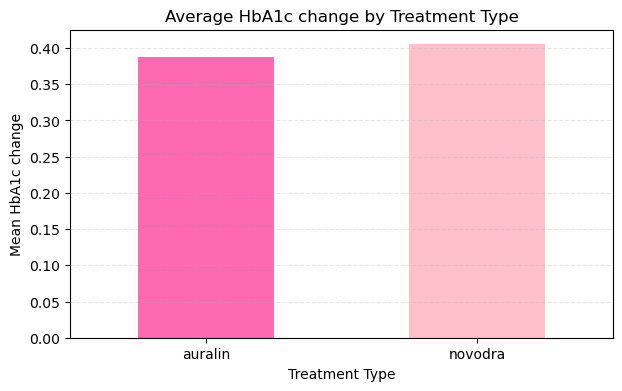

In [315]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
treatments_effectivness.plot(kind ='bar',color=['#FF69B4','pink'])
plt.xlabel('Treatment Type')
plt.ylabel('Mean HbA1c change')
plt.title('Average HbA1c change by Treatment Type')
plt.grid(axis = 'y',linestyle='--',alpha = 0.3)
plt.xticks(rotation=0)
plt.show()

#### hence,  Novodra appears marginally more effective in lowering blood sugar levels in this dataset.

#### 2. Relationship between body mass index categories and changes in HbA1c levels.

In [274]:
import pandas as pd
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
treatments_df2['BMI_Category'] = treatments_df2['bmi'].apply(bmi_category)

                  mean  median       std  count
BMI_Category                                   
Normal        0.394766    0.39  0.054382    128
Obese         0.398051    0.41  0.064480    118
Overweight    0.391789    0.39  0.058053     95
Underweight   0.438571    0.46  0.057280      7


In [280]:
bmi_hba1c_mean= treatments_df2.groupby('BMI_Category')['hba1c_change'].mean()
print(bmi_hba1c_mean)

BMI_Category
Normal         0.394766
Obese          0.398051
Overweight     0.391789
Underweight    0.438571
Name: hba1c_change, dtype: float64


In [275]:
treatments_df2

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,treatments_start,treatments_end,adverse_reaction,patient_id,...,city,state,country,birthdate,weight,height,bmi,email,phone,BMI_Category
0,Jožka,Resanovič,7.56,7.22,0.34,auralin,22,30,No reaction,468.0,...,Redding,California,United States,10/5/1959,122.1,63.0,21.6,JozkaResanovic@superrito.com,5307739263,Normal
1,Inunnguaq,Heilmann,7.85,7.45,0.40,auralin,57,67,No reaction,107.0,...,New Castle,IN,United States,5/6/1976,219.9,67.0,34.4,InunnguaqHeilmann@rhyta.com,1765599884,Obese
2,Alwin,Svensson,7.78,7.34,0.44,auralin,36,39,No reaction,438.0,...,Union Grove,WI,United States,11/2/1924,137.7,63.0,24.4,AlwinSvensson@armyspy.com,2628789576,Normal
3,Amanda,Ribeiro,7.85,7.47,0.38,auralin,36,44,No reaction,144.0,...,Seattle,WA,United States,9/27/1970,131.1,60.0,25.6,AmandaCavalcantiRibeiro@fleckens.hu,2069020473,Overweight
4,Sara,Miles,7.53,7.12,0.41,auralin,30,35,No reaction,260.0,...,Tampa,FL,United States,3/27/1982,166.5,61.0,31.5,SaraDMiles@gustr.com,7274397150,Obese
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,Yasmin,Araujo,7.82,7.36,0.46,novodra,51,54,No reaction,59.0,...,Pittsburgh,PA,United States,3/21/1981,196.0,67.0,30.7,YasminCardosoAraujo@superrito.com,4126407035,Obese
345,Hiromu,Horikawa,7.77,7.28,0.49,novodra,47,46,No reaction,440.0,...,Des Moines,IA,United States,7/7/1981,242.0,70.0,34.7,HiromuHorikawa@superrito.com,1515362657,Obese
346,Leo,Vieira,7.74,7.36,0.38,novodra,30,33,No reaction,434.0,...,Pittsburgh,PA,United States,3/9/1975,154.4,71.0,21.5,LeoDVieira@cuvox.de,4124490733,Normal
347,Steven,Roy,7.87,7.43,0.44,novodra,41,43,headache,394.0,...,Reston,VA,United States,9/19/1975,162.4,72.0,22.0,StevenBRoy@rhyta.com,1703716865,Normal


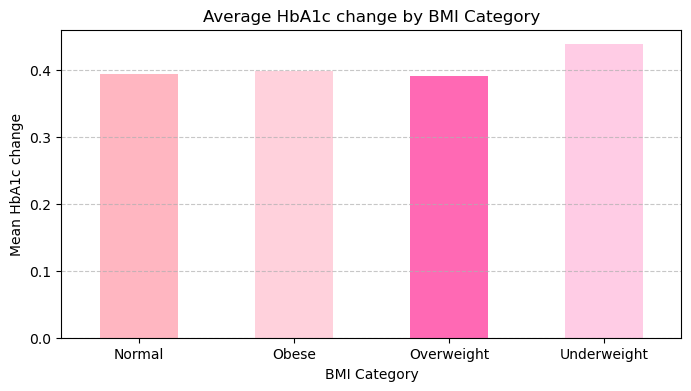

In [325]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
bmi_hba1c_mean.plot(kind ='bar',color=['#FFB6C1', '#FFD1DC', '#FF69B4', '#FFCCE5'])
plt.xlabel('BMI Category')
plt.ylabel('Mean HbA1c change')
plt.title('Average HbA1c change by BMI Category')
plt.grid(axis = 'y',linestyle='--',alpha = 0.7)
plt.xticks(rotation=0)
plt.show()

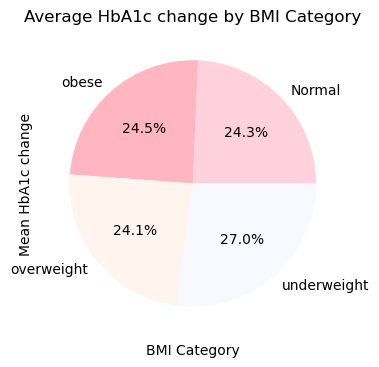

In [324]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.pie(bmi_hba1c_mean,colors=['#FFD1DC', '#FFB6C1', '#FFF5EE', '#F8F8FF'],autopct='%0.1f%%',labels = ['Normal','obese','overweight','underweight'])
plt.xlabel('BMI Category')
plt.ylabel('Mean HbA1c change')
plt.title('Average HbA1c change by BMI Category')
plt.grid(axis = 'y',linestyle='--',alpha = 0.7)
plt.xticks(rotation=0)
plt.show()

#### Hence,HbA1c averages are almost the same across BMI groups (24–27%). Even underweight individuals show the highest average at 27%. This makes it clear that diabetes risk is not defined by BMI alone. Genetics, lifestyle, age, and fat distribution inside the body all play a major role.

#### 3. Finding state wise BMI Category distribution

In [350]:
len(treatments_df2['state'].unique())

49

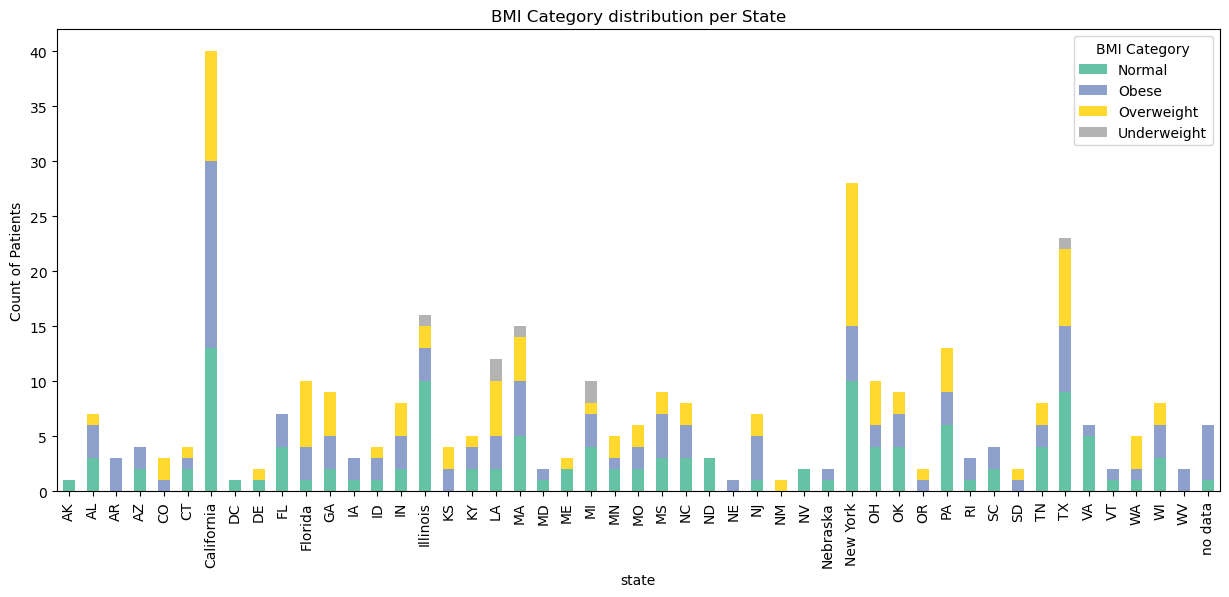

In [383]:
import matplotlib.pyplot as plt
state_bmi = treatments_df2.groupby(['state','BMI_Category']).size().unstack(fill_value=0)
state_bmi.plot(kind = 'bar' , colormap = 'Set2',stacked =True, figsize=(15,6))
plt.xlabel('state')
plt.ylabel('Count of Patients')
plt.title('BMI Category distribution per State')
plt.legend(title='BMI Category')
plt.xticks(rotation=90)
plt.savefig('sample.png')

#### Hence,California, New York and Texas(TX) show the highest patient counts, with a strong dominance of Obese and Overweight categories. In contrast, several smaller states have a higher share of Normal BMI, though total counts are lower. The presence of Underweight is minimal across most states.